<a href="https://colab.research.google.com/github/dhanase731/ds_day_1/blob/question_2/question_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("household_data_15min_singleindex.csv")

print(df.shape)
print(df.columns)
df.head()

(47465, 12)
Index(['utc_timestamp', 'cet_cest_timestamp', 'DE_KN_residential4_dishwasher',
       'DE_KN_residential4_ev', 'DE_KN_residential4_freezer',
       'DE_KN_residential4_grid_export', 'DE_KN_residential4_grid_import',
       'DE_KN_residential4_heat_pump', 'DE_KN_residential4_pv',
       'DE_KN_residential4_refrigerator', 'DE_KN_residential4_washing_machine',
       'interpolated_values'],
      dtype='object')


,utc_timestamp,cet_cest_timestamp,DE_KN_residential4_dishwasher,DE_KN_residential4_ev,DE_KN_residential4_freezer,DE_KN_residential4_grid_export,DE_KN_residential4_grid_import,DE_KN_residential4_heat_pump,DE_KN_residential4_pv,DE_KN_residential4_refrigerator,DE_KN_residential4_washing_machine,interpolated_values
0,2015-10-04T01:30:00Z,2015-10-04T03:30:00+0200,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN
1,2015-10-04T01:45:00Z,2015-10-04T03:45:00+0200,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN
2,2015-10-04T02:00:00Z,2015-10-04T04:00:00+0200,NaN,NaN,NaN,NaN,NaN,0.01,NaN,NaN,NaN,NaN
3,2015-10-04T02:15:00Z,2015-10-04T04:15:00+0200,NaN,NaN,NaN,NaN,NaN,0.01,NaN,NaN,NaN,NaN
4,2015-10-04T02:30:00Z,2015-10-04T04:30:00+0200,NaN,NaN,NaN,NaN,NaN,0.01,NaN,NaN,NaN,NaN


In [9]:
print(df.head())
print()
print(df.info())
print()
print(df.isnull().sum())

          utc_timestamp        cet_cest_timestamp  \
0  2015-10-04T01:30:00Z  2015-10-04T03:30:00+0200   
1  2015-10-04T01:45:00Z  2015-10-04T03:45:00+0200   
2  2015-10-04T02:00:00Z  2015-10-04T04:00:00+0200   
3  2015-10-04T02:15:00Z  2015-10-04T04:15:00+0200   
4  2015-10-04T02:30:00Z  2015-10-04T04:30:00+0200   

   DE_KN_residential4_dishwasher  DE_KN_residential4_ev  \
0                            NaN                    NaN   
1                            NaN                    NaN   
2                            NaN                    NaN   
3                            NaN                    NaN   
4                            NaN                    NaN   

   DE_KN_residential4_freezer  DE_KN_residential4_grid_export  \
0                         NaN                             NaN   
1                         NaN                             NaN   
2                         NaN                             NaN   
3                         NaN                             NaN   
4

In [10]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['utc_timestamp', 'cet_cest_timestamp', 'DE_KN_residential4_dishwasher', 'DE_KN_residential4_ev', 'DE_KN_residential4_freezer', 'DE_KN_residential4_grid_export', 'DE_KN_residential4_grid_import', 'DE_KN_residential4_heat_pump', 'DE_KN_residential4_pv', 'DE_KN_residential4_refrigerator', 'DE_KN_residential4_washing_machine', 'interpolated_values']


In [11]:
df["timestamp"] = pd.to_datetime(
    df["cet_cest_timestamp"],
    errors="coerce"
)

df = df.dropna(subset=["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)

print("First timestamp:")
print(df["timestamp"].min())

print("\nLast timestamp:")
print(df["timestamp"].max())

First timestamp:
2015-10-04 03:30:00+02:00

Last timestamp:
2017-02-09 12:30:00+01:00


/tmp/ipykernel_956/2050327274.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["timestamp"] = pd.to_datetime(


In [12]:
df["Household_ID"] = "DE_KN_residential4"

print(df["Household_ID"].unique())

['DE_KN_residential4']


In [13]:
grid_import = "DE_KN_residential4_grid_import"

df[grid_import] = pd.to_numeric(
    df[grid_import],
    errors="coerce"
)

df["Electricity_Consumption"] = (
    df[grid_import].diff()
)

In [14]:
df["Electricity_Consumption"] = (
    df["Electricity_Consumption"]
    .fillna(0)
)

df["Electricity_Consumption"] = (
    df["Electricity_Consumption"]
    .clip(lower=0)
)

print(
    df[
        [
            "timestamp",
            grid_import,
            "Electricity_Consumption"
        ]
    ].head(15)
)

                    timestamp  DE_KN_residential4_grid_import  \
0   2015-10-04 03:30:00+02:00                             NaN   
1   2015-10-04 03:45:00+02:00                             NaN   
2   2015-10-04 04:00:00+02:00                             NaN   
3   2015-10-04 04:15:00+02:00                             NaN   
4   2015-10-04 04:30:00+02:00                             NaN   
5   2015-10-04 04:45:00+02:00                             NaN   
6   2015-10-04 05:00:00+02:00                             NaN   
7   2015-10-04 05:15:00+02:00                             NaN   
8   2015-10-04 05:30:00+02:00                             NaN   
9   2015-10-04 05:45:00+02:00                             NaN   
10  2015-10-04 06:00:00+02:00                             NaN   
11  2015-10-04 06:15:00+02:00                             NaN   
12  2015-10-04 06:30:00+02:00                             NaN   
13  2015-10-04 06:45:00+02:00                             NaN   
14  2015-10-04 07:00:00+0

In [16]:
import pandas as pd

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)

df["Hour"] = df["timestamp"].dt.hour

df["Day"] = df["timestamp"].dt.day

df["Day_of_Week"] = df["timestamp"].dt.dayofweek

df["Month"] = df["timestamp"].dt.month

df["Date"] = df["timestamp"].dt.date

df["Month_Period"] = (
    df["timestamp"].dt.to_period("M")
)

/tmp/ipykernel_956/2718070345.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["timestamp"].dt.to_period("M")


In [17]:
df["Day_Type"] = np.where(
    df["Day_of_Week"] >= 5,
    "Weekend",
    "Weekday"
)

In [18]:
print(
    df[
        [
            "timestamp",
            "Hour",
            "Day",
            "Day_of_Week",
            "Month",
            "Day_Type"
        ]
    ].head()
)

                  timestamp  Hour  Day  Day_of_Week  Month Day_Type
0 2015-10-04 01:30:00+00:00     1    4            6     10  Weekend
1 2015-10-04 01:45:00+00:00     1    4            6     10  Weekend
2 2015-10-04 02:00:00+00:00     2    4            6     10  Weekend
3 2015-10-04 02:15:00+00:00     2    4            6     10  Weekend
4 2015-10-04 02:30:00+00:00     2    4            6     10  Weekend


In [19]:
print("Total consumption:",
      df["Electricity_Consumption"].sum(),
      "kWh")



Total consumption: 6238.302 kWh


In [20]:
print("Average 15-minute consumption:",
      df["Electricity_Consumption"].mean(),
      "kWh")

Average 15-minute consumption: 0.13142951648583165 kWh


In [21]:
print("Maximum 15-minute consumption:",
      df["Electricity_Consumption"].max(),
      "kWh")

Maximum 15-minute consumption: 1.4480000000003201 kWh


In [22]:
print("Minimum 15-minute consumption:",
      df["Electricity_Consumption"].min(),
      "kWh")

Minimum 15-minute consumption: 0.0 kWh


In [23]:
print("Median 15-minute consumption:",
      df["Electricity_Consumption"].median(),
      "kWh")

Median 15-minute consumption: 0.06399999999985084 kWh


In [24]:
daily = (
    df.groupby("Date")["Electricity_Consumption"]
      .sum()
      .reset_index()
)

daily.columns = [
    "Date",
    "Daily_Consumption"
]

print(daily.head())
print("\nNumber of days:", len(daily))

         Date  Daily_Consumption
0  2015-10-04                0.0
1  2015-10-05                0.0
2  2015-10-06                0.0
3  2015-10-07                0.0
4  2015-10-08                0.0

Number of days: 495


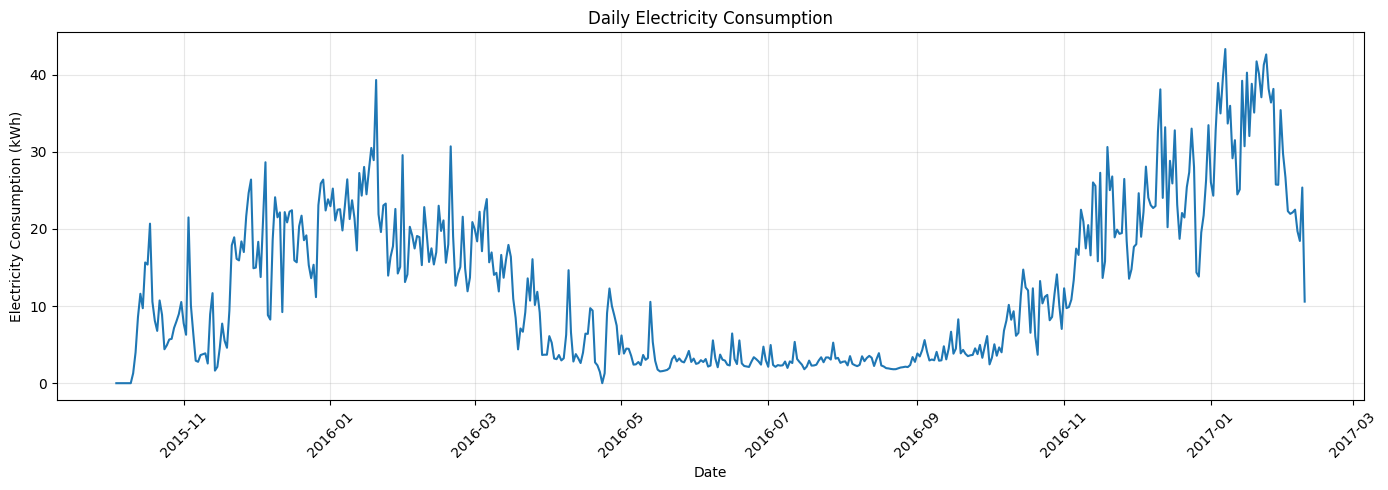

In [25]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily["Date"],
    daily["Daily_Consumption"]
)

plt.title("Daily Electricity Consumption")

plt.xlabel("Date")

plt.ylabel("Electricity Consumption (kWh)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [26]:
hourly = (
    df.groupby("Hour")["Electricity_Consumption"]
      .mean()
)

print(hourly)

Hour
0     0.136397
1     0.129738
2     0.126007
3     0.125945
4     0.125962
5     0.123707
6     0.134441
7     0.179842
8     0.134660
9     0.099513
10    0.085271
11    0.108916
12    0.112584
13    0.091020
14    0.090517
15    0.103095
16    0.134448
17    0.147782
18    0.155544
19    0.158535
20    0.165070
21    0.170430
22    0.165550
23    0.149467
Name: Electricity_Consumption, dtype: float64


In [27]:
peak_hour = hourly.idxmax()

peak_consumption = hourly.max()

print("Peak hour:", peak_hour)

print(
    "Average consumption during peak hour:",
    peak_consumption,
    "kWh per 15-minute interval"
)

Peak hour: 7
Average consumption during peak hour: 0.17984242424242483 kWh per 15-minute interval


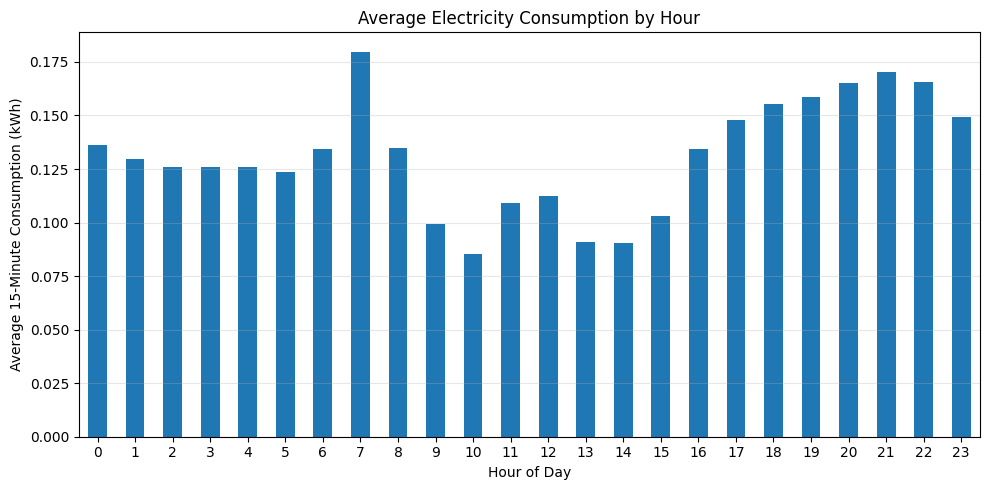

In [28]:
plt.figure(figsize=(10, 5))

hourly.sort_index().plot(kind="bar")

plt.title(
    "Average Electricity Consumption by Hour"
)

plt.xlabel("Hour of Day")

plt.ylabel(
    "Average 15-Minute Consumption (kWh)"
)

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [29]:
day_type_consumption = (
    df.groupby("Day_Type")
      ["Electricity_Consumption"]
      .sum()
)

print(day_type_consumption)

Day_Type
Weekday    4368.478
Weekend    1869.824
Name: Electricity_Consumption, dtype: float64


In [30]:
weekday_weekend = (
    daily.merge(
        df[
            ["Date", "Day_Type"]
        ].drop_duplicates(),
        on="Date"
    )
    .groupby("Day_Type")["Daily_Consumption"]
    .mean()
)

print(weekday_weekend)

Day_Type
Weekday    12.340333
Weekend    13.261163
Name: Daily_Consumption, dtype: float64


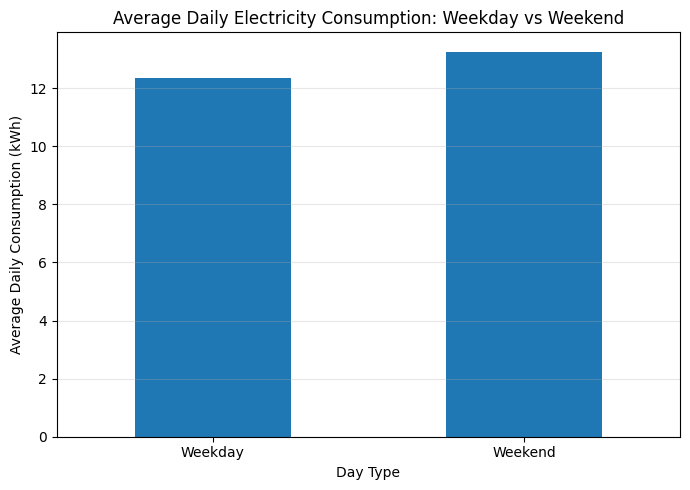

In [31]:
plt.figure(figsize=(7, 5))

weekday_weekend.plot(kind="bar")

plt.title(
    "Average Daily Electricity Consumption: Weekday vs Weekend"
)

plt.xlabel("Day Type")

plt.ylabel("Average Daily Consumption (kWh)")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [32]:
threshold_90 = (
    daily["Daily_Consumption"]
    .quantile(0.90)
)

high_consumption_days = daily[
    daily["Daily_Consumption"] >= threshold_90
]

print(
    "90th percentile threshold:",
    threshold_90,
    "kWh"
)

print(
    "Number of high-consumption days:",
    len(high_consumption_days)
)

print(high_consumption_days)

90th percentile threshold: 26.421799999999987 kWh
Number of high-consumption days: 50
           Date  Daily_Consumption
62   2015-12-05             28.648
96   2016-01-08             26.433
101  2016-01-13             27.255
103  2016-01-15             28.042
105  2016-01-17             27.645
106  2016-01-18             30.505
107  2016-01-19             28.920
108  2016-01-20             39.315
119  2016-01-31             29.572
139  2016-02-20             30.710
409  2016-11-16             27.282
412  2016-11-19             30.627
414  2016-11-21             26.807
419  2016-11-26             26.485
428  2016-12-05             28.084
433  2016-12-10             32.640
434  2016-12-11             38.099
436  2016-12-13             33.189
438  2016-12-15             28.835
440  2016-12-17             32.789
446  2016-12-23             27.346
447  2016-12-24             33.012
448  2016-12-25             28.023
454  2016-12-31             33.459
457  2017-01-03             32.801
458 

In [33]:
Q1 = daily["Daily_Consumption"].quantile(0.25)

Q3 = daily["Daily_Consumption"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

anomalies = daily[
    (daily["Daily_Consumption"] < lower_limit) |
    (daily["Daily_Consumption"] > upper_limit)
]

print("Q1:", Q1)

print("Q3:", Q3)

print("IQR:", IQR)

print("Upper limit:", upper_limit)

print(
    "Number of anomalous days:",
    len(anomalies)
)

print(anomalies)

Q1: 3.274499999999989
Q3: 20.317999999999984
IQR: 17.043499999999995
Upper limit: 45.883249999999975
Number of anomalous days: 0
Empty DataFrame
Columns: [Date, Daily_Consumption]
Index: []


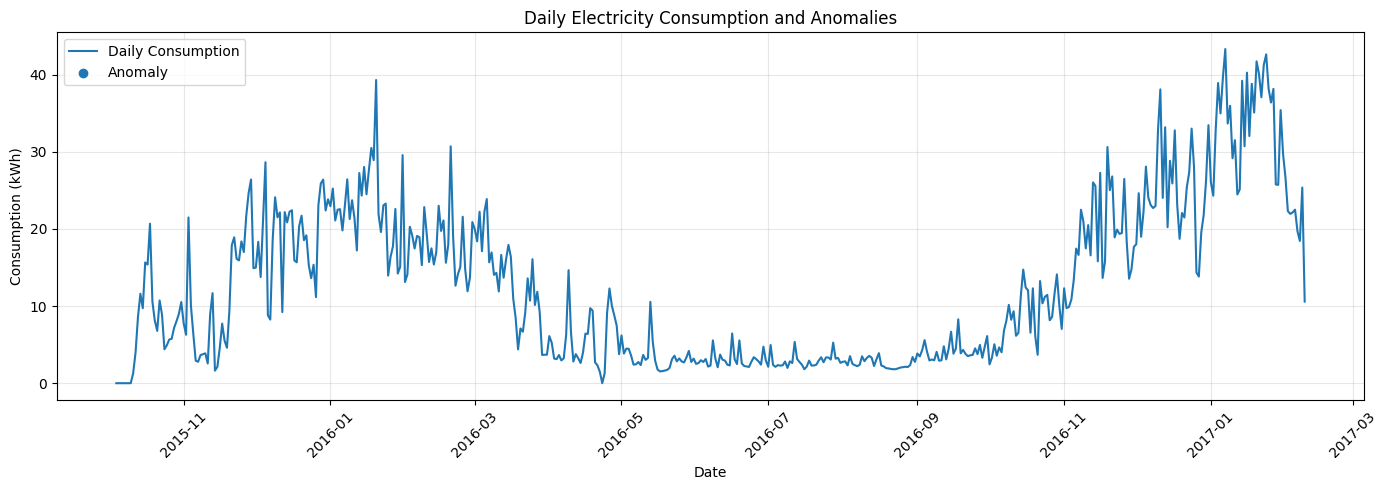

In [34]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily["Date"],
    daily["Daily_Consumption"],
    label="Daily Consumption"
)

plt.scatter(
    anomalies["Date"],
    anomalies["Daily_Consumption"],
    label="Anomaly"
)

plt.title(
    "Daily Electricity Consumption and Anomalies"
)

plt.xlabel("Date")

plt.ylabel("Consumption (kWh)")

plt.xticks(rotation=45)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [35]:
appliance_columns = {
    "Dishwasher":
        "DE_KN_residential4_dishwasher",

    "EV":
        "DE_KN_residential4_ev",

    "Freezer":
        "DE_KN_residential4_freezer",

    "Heat Pump":
        "DE_KN_residential4_heat_pump",

    "Refrigerator":
        "DE_KN_residential4_refrigerator",

    "Washing Machine":
        "DE_KN_residential4_washing_machine"
}

In [36]:
for appliance, column in appliance_columns.items():

    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

    df[appliance] = (
        df[column]
        .diff()
        .clip(lower=0)
        .fillna(0)
    )

In [37]:
print(
    df[
        [
            "Dishwasher",
            "EV",
            "Freezer",
            "Heat Pump",
            "Refrigerator",
            "Washing Machine"
        ]
    ].head()
)

   Dishwasher   EV  Freezer  Heat Pump  Refrigerator  Washing Machine
0         0.0  0.0      0.0       0.00           0.0              0.0
1         0.0  0.0      0.0       0.00           0.0              0.0
2         0.0  0.0      0.0       0.01           0.0              0.0
3         0.0  0.0      0.0       0.00           0.0              0.0
4         0.0  0.0      0.0       0.00           0.0              0.0


In [38]:
appliance_totals = (
    df[
        [
            "Dishwasher",
            "EV",
            "Freezer",
            "Heat Pump",
            "Refrigerator",
            "Washing Machine"
        ]
    ]
    .sum()
    .sort_values(ascending=False)
)

print(appliance_totals)

Heat Pump          4276.965
EV                 1326.048
Freezer             200.300
Refrigerator        189.811
Washing Machine     148.656
Dishwasher          116.031
dtype: float64


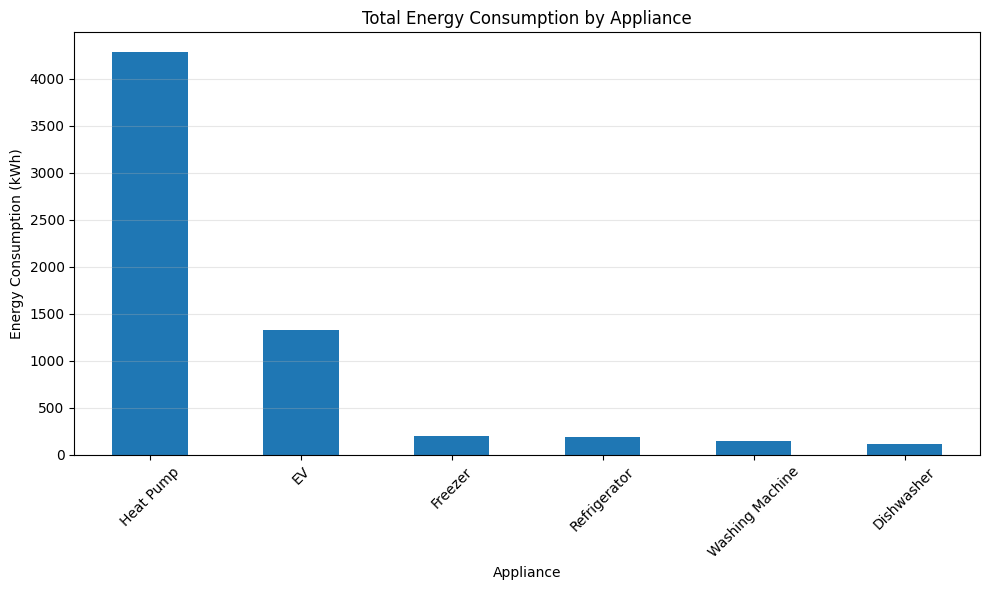

In [39]:
plt.figure(figsize=(10, 6))

appliance_totals.plot(kind="bar")

plt.title(
    "Total Energy Consumption by Appliance"
)

plt.xlabel("Appliance")

plt.ylabel("Energy Consumption (kWh)")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [40]:
df["Hour_sin"] = np.sin(
    2 * np.pi * df["Hour"] / 24
)

df["Hour_cos"] = np.cos(
    2 * np.pi * df["Hour"] / 24
)

df["Day_sin"] = np.sin(
    2 * np.pi * df["Day_of_Week"] / 7
)

df["Day_cos"] = np.cos(
    2 * np.pi * df["Day_of_Week"] / 7
)

In [41]:
features = [
    "Hour_sin",
    "Hour_cos",
    "Day_sin",
    "Day_cos",
    "Dishwasher",
    "EV",
    "Freezer",
    "Heat Pump",
    "Refrigerator",
    "Washing Machine"
]

target = "Electricity_Consumption"

In [42]:
model_df = df[
    features + [target]
].copy()

model_df = model_df.dropna()

print(model_df.shape)

print(model_df.head())

(47465, 11)
   Hour_sin  Hour_cos   Day_sin  Day_cos  Dishwasher   EV  Freezer  Heat Pump  \
0  0.258819  0.965926 -0.781831  0.62349         0.0  0.0      0.0       0.00   
1  0.258819  0.965926 -0.781831  0.62349         0.0  0.0      0.0       0.00   
2  0.500000  0.866025 -0.781831  0.62349         0.0  0.0      0.0       0.01   
3  0.500000  0.866025 -0.781831  0.62349         0.0  0.0      0.0       0.00   
4  0.500000  0.866025 -0.781831  0.62349         0.0  0.0      0.0       0.00   

   Refrigerator  Washing Machine  Electricity_Consumption  
0           0.0              0.0                      0.0  
1           0.0              0.0                      0.0  
2           0.0              0.0                      0.0  
3           0.0              0.0                      0.0  
4           0.0              0.0                      0.0  


In [43]:
split_index = int(
    len(model_df) * 0.80
)

train = model_df.iloc[:split_index]

test = model_df.iloc[split_index:]

X_train = train[features]

y_train = train[target]

X_test = test[features]

y_test = test[target]

print("Training rows:", len(train))

print("Testing rows:", len(test))

Training rows: 37972
Testing rows: 9493


In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [47]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

predictions = knn.predict(
    X_test_scaled
)

print(predictions[:10])

[0.006  0.006  0.0044 0.0954 0.059  0.0864 0.     0.     0.1014 0.0096]


In [48]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)

print("RMSE:", rmse)

print("R²  :", r2)

MAE : 0.08371408406194261
RMSE: 0.13799528714107467
R²  : 0.5736153579194331


In [49]:
results = []

for k in range(1, 21):

    model = KNeighborsRegressor(
        n_neighbors=k
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    pred = model.predict(
        X_test_scaled
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    results.append({
        "K": k,
        "RMSE": rmse
    })

results_df = pd.DataFrame(results)

print(results_df)

     K      RMSE
0    1  0.159716
1    2  0.145791
2    3  0.141171
3    4  0.138464
4    5  0.137995
5    6  0.137310
6    7  0.137028
7    8  0.136558
8    9  0.137000
9   10  0.137036
10  11  0.137222
11  12  0.137309
12  13  0.137651
13  14  0.137930
14  15  0.138200
15  16  0.138187
16  17  0.138393
17  18  0.138570
18  19  0.138849
19  20  0.138995


In [50]:
best_row = results_df.loc[
    results_df["RMSE"].idxmin()
]

print("Best K:", int(best_row["K"]))

print("Best RMSE:", best_row["RMSE"])

Best K: 8
Best RMSE: 0.13655753371727322


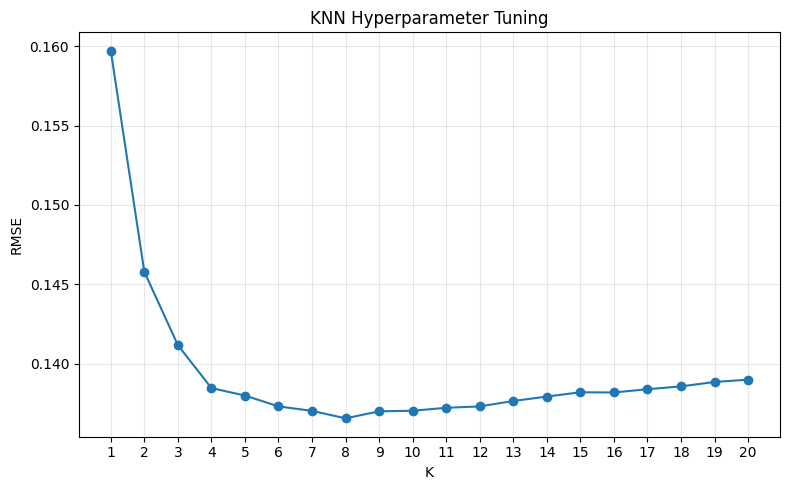

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["K"],
    results_df["RMSE"],
    marker="o"
)

plt.title(
    "KNN Hyperparameter Tuning"
)

plt.xlabel("K")

plt.ylabel("RMSE")

plt.xticks(range(1, 21))

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [52]:
best_k = int(best_row["K"])

final_knn = KNeighborsRegressor(
    n_neighbors=best_k
)

final_knn.fit(
    X_train_scaled,
    y_train
)

final_predictions = final_knn.predict(
    X_test_scaled
)

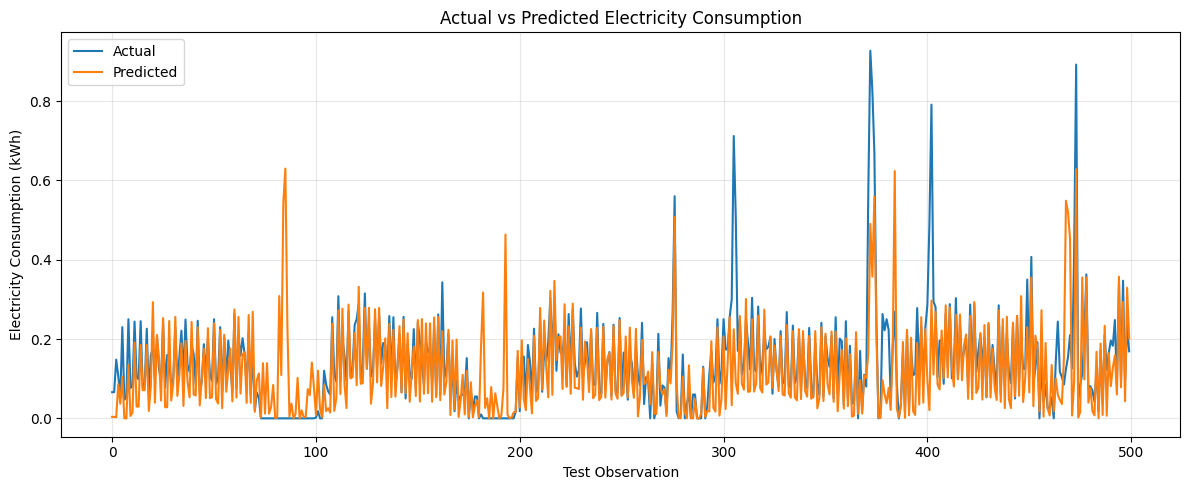

In [53]:
limit = min(500, len(y_test))

plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values[:limit],
    label="Actual"
)

plt.plot(
    final_predictions[:limit],
    label="Predicted"
)

plt.title(
    "Actual vs Predicted Electricity Consumption"
)

plt.xlabel("Test Observation")

plt.ylabel("Electricity Consumption (kWh)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [54]:
print("=" * 60)
print("FINAL PROJECT RESULTS")
print("=" * 60)

print(
    "Total observations:",
    len(df)
)

print(
    "Household:",
    df["Household_ID"].iloc[0]
)

print(
    "Total electricity consumption:",
    round(
        df["Electricity_Consumption"].sum(),
        3
    ),
    "kWh"
)

print(
    "Average 15-minute consumption:",
    round(
        df["Electricity_Consumption"].mean(),
        5
    ),
    "kWh"
)

print(
    "Peak hour:",
    peak_hour
)

print(
    "90th percentile daily consumption:",
    round(
        threshold_90,
        3
    ),
    "kWh"
)

print(
    "High-consumption days:",
    len(high_consumption_days)
)

print(
    "Anomalous days:",
    len(anomalies)
)

print(
    "Highest appliance feed:",
    appliance_totals.index[0]
)

print(
    "Highest appliance consumption:",
    round(
        appliance_totals.iloc[0],
        3
    ),
    "kWh"
)

print(
    "Best K:",
    best_k
)

print(
    "Final KNN RMSE:",
    round(
        np.sqrt(
            mean_squared_error(
                y_test,
                final_predictions
            )
        ),
        5
    )
)

print(
    "Final KNN R²:",
    round(
        r2_score(
            y_test,
            final_predictions
        ),
        5
    )
)

FINAL PROJECT RESULTS
Total observations: 47465
Household: DE_KN_residential4
Total electricity consumption: 6238.302 kWh
Average 15-minute consumption: 0.13143 kWh
Peak hour: 7
90th percentile daily consumption: 26.422 kWh
High-consumption days: 50
Anomalous days: 0
Highest appliance feed: Heat Pump
Highest appliance consumption: 4276.965 kWh
Best K: 8
Final KNN RMSE: 0.13656
Final KNN R²: 0.58245
